# Default数据

In [18]:
import numpy as np
from matplotlib import pyplot as plt
import torch

# SSIM, PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR



epoch = 16
slice = 16
data_range = 2.0 # -1~1


ssim = SSIM(data_range=data_range)
psnr = PSNR(data_range=data_range)

fake_mri.shape: torch.Size([1, 1, 32, 256, 256])
real ct:	 0.0000  51.2650  255.0000
fake mri:	 -1.0000  -0.7921  0.2317
real mri:	 -1.0000  -0.7729  1.0000
real mask:	 0.0000  0.4654  1.0000


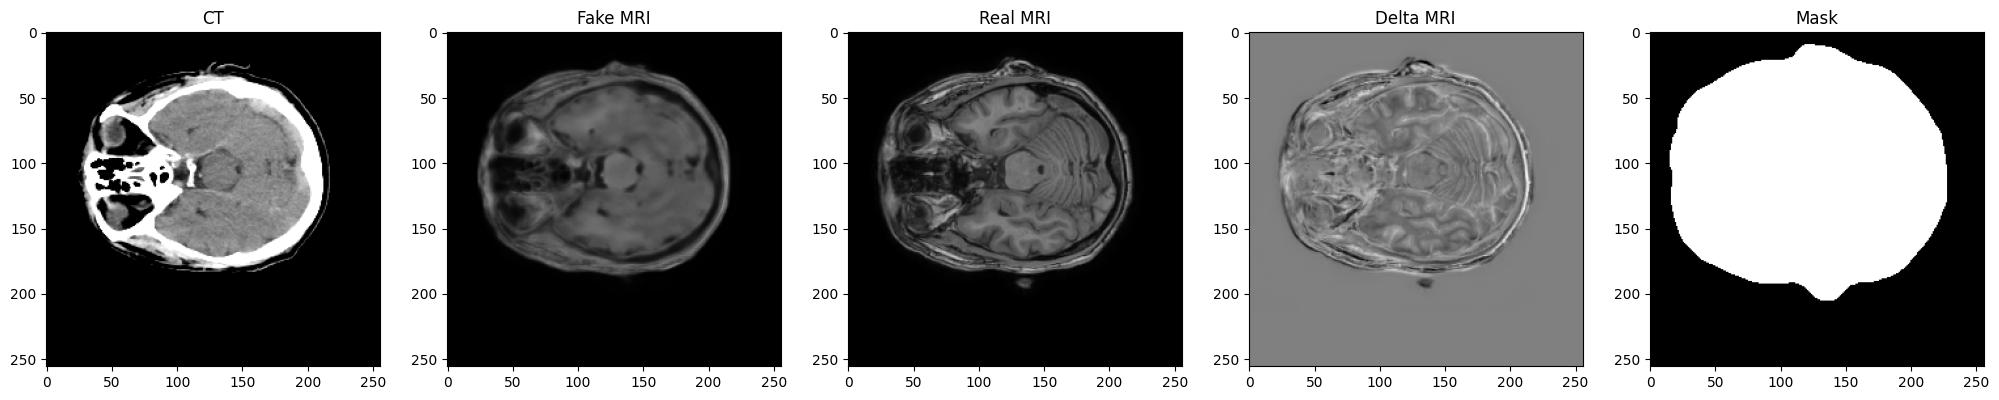

SSIM: 0.7654017210006714, PSNR: 24.067520141601562


In [19]:
real_ct_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


fake_mri.shape: torch.Size([1, 1, 32, 256, 256])
real ct:	 0.0000  39.5403  255.0000
fake mri:	 -1.0000  -0.8496  0.5252
real mri:	 -1.0000  -0.8545  1.0000
real mask:	 0.0000  0.4382  1.0000


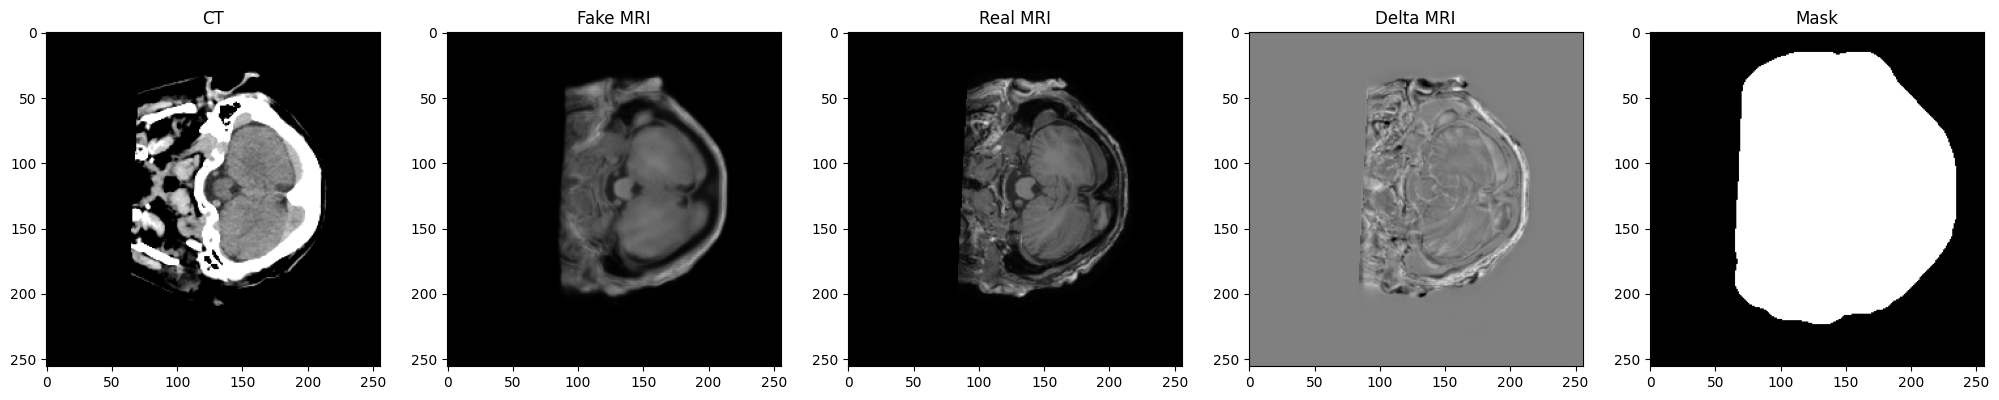

SSIM: 0.8485438823699951, PSNR: 25.31538200378418


In [20]:
real_ct_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


In [21]:
# 手动算fake_mri, real_mri的psnr
def get_psnr(img1, img2, data_range=2.0):
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf') 
    # return 10 * torch.log10(data_range ** 2 / mse) # 原式
    return 20 * torch.log10(data_range / torch.sqrt(mse)) # 化简

print(get_psnr(fake_mri, real_mri))

tensor(25.3154)


# Liu数据

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch

# SSIM, PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR



epoch = 201
slice = 16
data_range = 2.0 # -1~1


ssim = SSIM(data_range=data_range)
psnr = PSNR(data_range=data_range)

fake_mri.shape: torch.Size([1, 1, 64, 256, 256])
real ct:	 0.0000  22.9786  125.0000
fake mri:	 -1.0000  -0.7992  0.7156
real mri:	 -1.0000  -0.8195  0.5608
real mask:	 1.0000  1.0000  1.0000


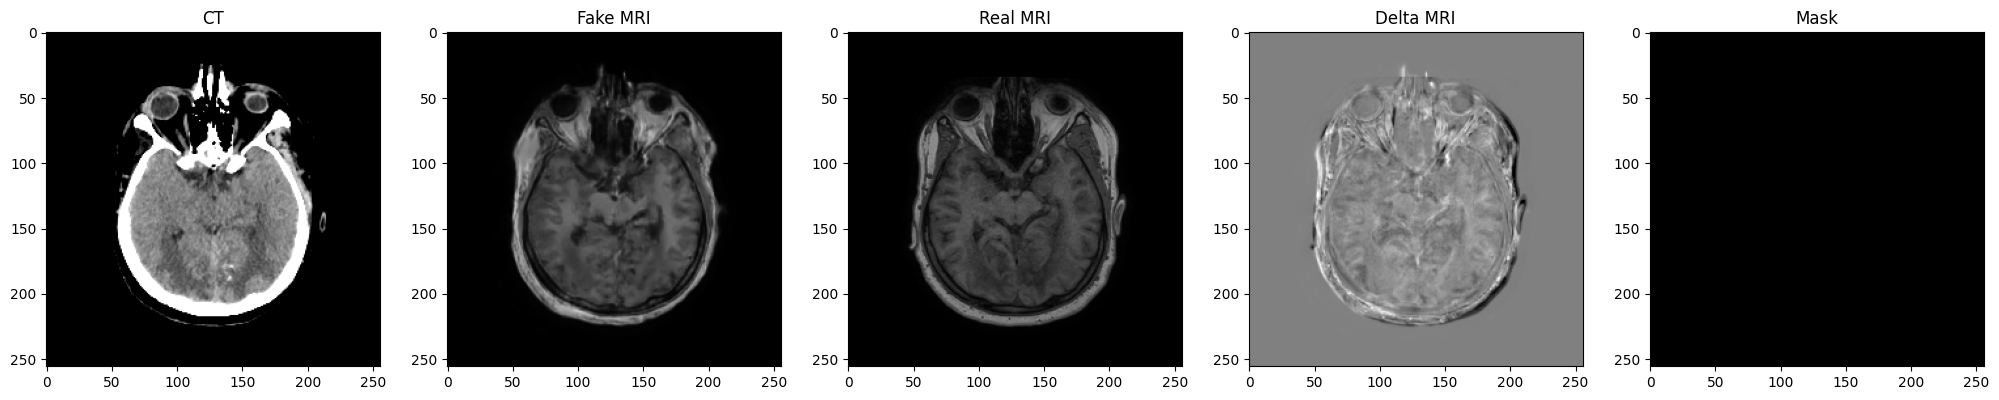

SSIM: 0.8130562901496887, PSNR: 24.128156661987305


In [2]:
real_ct_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


fake_mri.shape: torch.Size([1, 1, 64, 256, 256])
real ct:	 0.0000  28.7814  146.0000
fake mri:	 -1.0000  -0.7760  0.6912
real mri:	 -1.0000  -0.7743  0.6784
real mask:	 1.0000  1.0000  1.0000


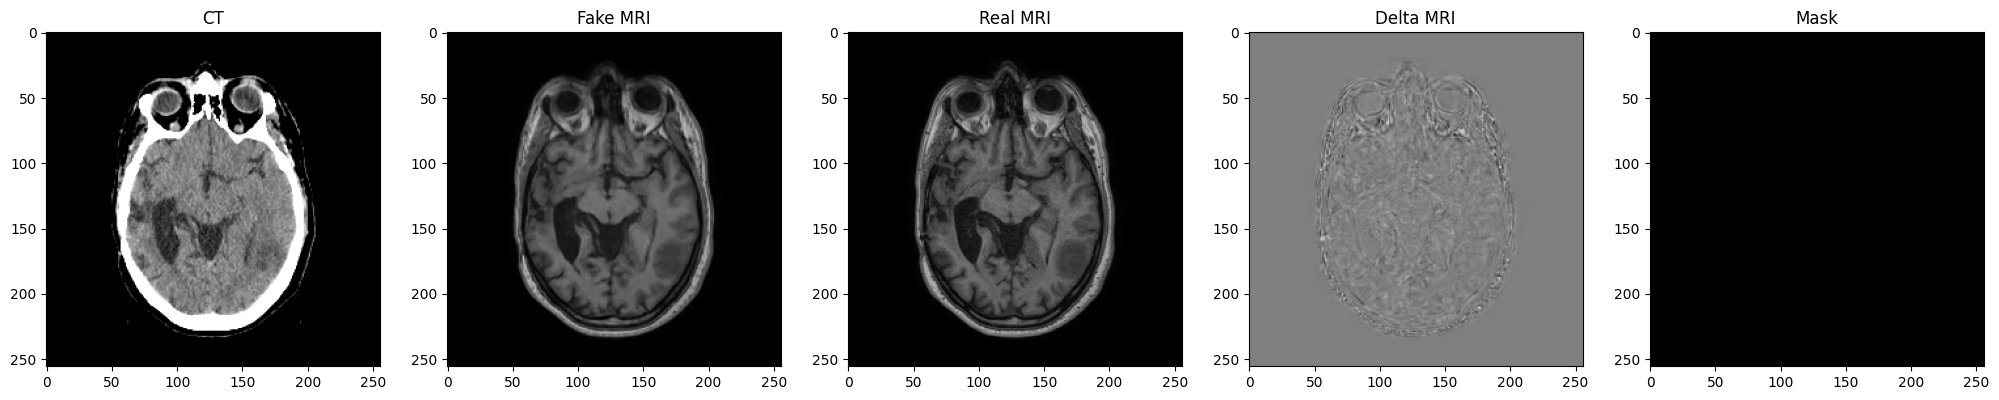

SSIM: 0.9254604578018188, PSNR: 30.777061462402344


In [ ]:
real_ct_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')
